<a href="https://colab.research.google.com/github/STLNFTART/MotorHandPro/blob/main/notebooks/biomedical/03_drug_safety.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Drug Safety Modeling

Pharmacokinetic modeling and drug safety assessment using Primal Logic.

In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip install numpy matplotlib pandas
    !git clone https://github.com/STLNFTART/MotorHandPro.git
    sys.path.append('/content/MotorHandPro')
else:
    sys.path.append('..' if 'notebooks' not in str(Path.cwd()) else '../..')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

Cloning into 'MotorHandPro'...
remote: Enumerating objects: 6967, done.
remote: Counting objects: 100% (252/252), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 6967 (delta 205), reused 200 (delta 178), pack-reused 6715 (from 1)
Receiving objects: 100% (6967/6967), 62.33 MiB | 22.96 MiB/s, done.
Resolving deltas: 100% (1359/1359), done.


## Pharmacokinetic Model

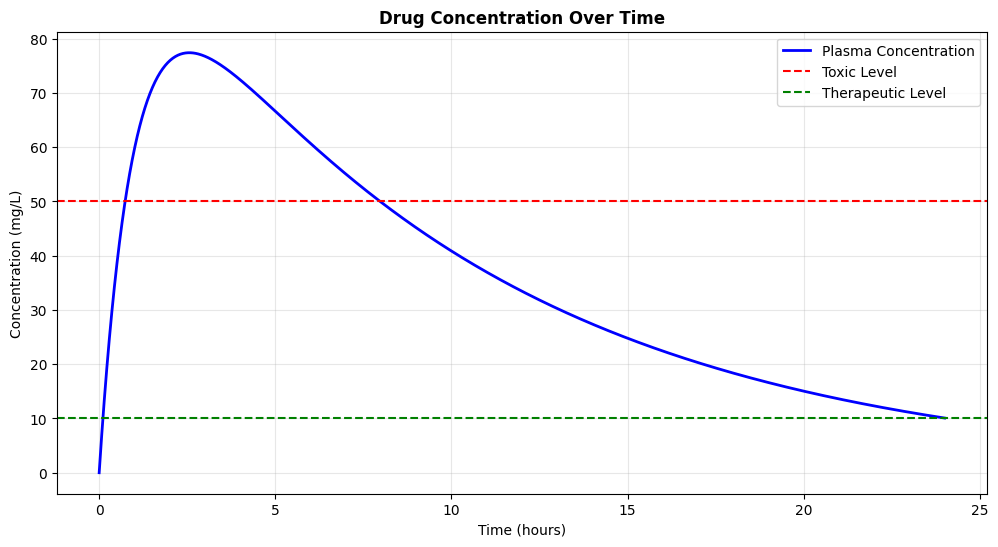

In [2]:
def pk_model(t, dose=100, ka=1.0, ke=0.1):
    # One-compartment PK model
    C = dose * ka / (ka - ke) * (np.exp(-ke * t) - np.exp(-ka * t))
    return C

t = np.linspace(0, 24, 1000)
C = pk_model(t)

plt.figure(figsize=(12, 6))
plt.plot(t, C, 'b-', linewidth=2, label='Plasma Concentration')
plt.axhline(y=50, color='r', linestyle='--', label='Toxic Level')
plt.axhline(y=10, color='g', linestyle='--', label='Therapeutic Level')
plt.xlabel('Time (hours)')
plt.ylabel('Concentration (mg/L)')
plt.title('Drug Concentration Over Time', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()